# Notebook de processamento dos dados extraidos

Esse notebook transforma a base bruta posts.parquet em um dataset analítico para modelagem e análise exploratória

# 0. Configuração

In [7]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

In [8]:
# Estilo global dos gráficos
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [9]:
PARQUET_POSTS = Path("posts.parquet")
CSV_INFLUENCERS = Path("dataframe_influencers.csv")
PARQUET_ANALITICO = Path("posts_com_comentarios.parquet")
PARQUET_PROCESSADO = Path("posts_processado.parquet")

In [10]:
ORDEM_BUCKET = ["nano", "micro", "mid-tier", "macro", "mega"]
ORDEM_ER_IND = ["LOW", "MEDIUM", "HIGH", "VIRAL"]
ORDEM_ER_PERC = ["Q1", "Q2", "Q3", "Q4"]

## 0.1 Carregar a base bruta

In [2]:
df = pl.read_parquet(PARQUET_POSTS)

In [3]:
df.shape

(9726198, 20)

In [4]:
df.estimated_size("mb")

1393.76331615448

In [5]:
df.schema

Schema([('post_id', String),
        ('username', String),
        ('inf_category', String),
        ('followers', Int64),
        ('followees', Int64),
        ('posts_total', Int64),
        ('is_verified', Boolean),
        ('data', String),
        ('timestamp_unix', Int64),
        ('likes', Int64),
        ('comments_count', Int64),
        ('post_type', String),
        ('n_imagens', Int64),
        ('aspect_ratio', Float64),
        ('is_sponsored', Boolean),
        ('n_hashtags', Int64),
        ('n_usertags', Int64),
        ('caption_len', Int64),
        ('has_location', Boolean),
        ('accessibility', String)])

# 1.0 Qualidade e integridade dos dados

## 1.1 Valores nulos por coluna


In [14]:
df.null_count()

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 1.2 Influenciadores únicos e posts por perfil

In [17]:
posts_por_perfil = (
    df.group_by("username")
    .agg(pl.len().alias("n_posts"))
    .sort("n_posts", descending=True)
)
print(f"Influenciadores unicos: {posts_por_perfil.shape[0]}")

Influenciadores unicos: 33840


In [19]:
posts_por_perfil["n_posts"].describe()


statistic,value
str,f64
"""count""",33840.0
"""null_count""",0.0
"""mean""",287.417199
"""std""",37.518166
"""min""",1.0
"""25%""",297.0
"""50%""",300.0
"""75%""",300.0
"""max""",300.0


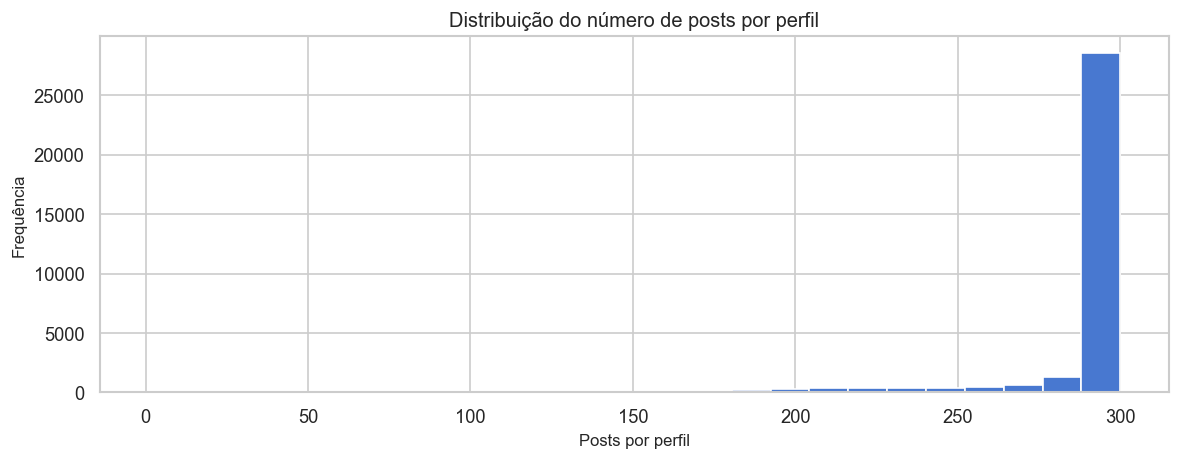

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(posts_por_perfil["n_posts"].to_numpy(), bins=25,
        color=sns.color_palette("muted")[0], edgecolor="white")
ax.set_title("Distribuição do número de posts por perfil")
ax.set_xlabel("Posts por perfil")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()


A grande maioria tem 300 posts

## 1.3 Cobertura do arquivo de influenciadores

- Quantos perfis da base de posts estão presentes no influencers.txt?
- Quantos perfis da base de posts não estavam no influencers.txt?
- Quantos posts são afetados por essa ausência?

In [ ]:
df_inf = pd.read_csv(CSV_INFLUENCERS)
print(f"Influenciadores no arquivo influencers.txt: {df_inf.shape[0]:,}")
df_inf.head()

Influenciadores no arquivo: 33,935


,Username,Category,Followers,Followees,Posts
0,makeupbynvs,beauty,1432,1089,363
1,jaquelinevandoski,beauty,137600,548,569
2,anisaartistry,beauty,64644,289,391
3,rubina_muartistry,beauty,496406,742,887
4,beautyxabbi,beauty,2050,1423,751


In [23]:
usernames_posts = set(df['username'].unique().to_list())
usernames_lookup = set(df_inf['Username'].astype(str).to_list())

In [24]:
perfis_completos = usernames_lookup & usernames_posts
perfis_faltantes = usernames_posts - usernames_lookup
perfis_sem_posts = usernames_lookup - usernames_posts

In [25]:
print('Perfis únicos na base de posts: ',len(usernames_posts))
print('Perfis únicos no dataframe_influencers.csv',len(usernames_lookup))
print('Perfis Completos: ',len(perfis_completos))
print('Perfis faltantes no lookup: ',len(perfis_faltantes))
print('Perfis no lookup sem posts na base: ',len(perfis_sem_posts))

Perfis únicos na base de posts:  33840
Perfis únicos no dataframe_influencers.csv 33935
Perfis Completos:  33149
Perfis faltantes no lookup:  691
Perfis no lookup sem posts na base:  786


In [29]:
# Flag de cobertura, perfil_no_lookup bool.
df = df.with_columns(
    pl.col("username").is_in(sorted(perfis_completos)).alias("perfil_no_lookup")
)

n_com  = df.filter( pl.col("perfil_no_lookup")).shape[0]
n_sem  = df.filter(~pl.col("perfil_no_lookup")).shape[0]
total  = df.shape[0]

print(f"Posts de perfis COMPLETOS no lookup  : {n_com}  ({n_com/total*100:.2f}%)")
print(f"Posts de perfis FALTANTES no lookup  : {n_sem}  ({n_sem/total*100:.2f}%)")


Posts de perfis COMPLETOS no lookup  : 9566651  (98.36%)
Posts de perfis FALTANTES no lookup  : 159547  (1.64%)


### Hipótese operacional

Espera-se que os perfis faltantes no lookup sejam os mesmos com `followers = 0` e `inf_category` vazia, pois essas colunas eram preenchidas exclusivamente via lookup.  
A célula abaixo valida essa hipótese.

In [31]:
validacao = (
    df.with_columns([
        (pl.col("followers") == 0).alias("followers_zero"),
        (pl.col("inf_category").is_null() | (pl.col("inf_category") == "")).alias("sem_categoria"),
    ])
    .group_by(["perfil_no_lookup", "followers_zero", "sem_categoria"])
    .agg(pl.len().alias("n_posts"))
    .sort("n_posts", descending=True)
)
validacao


perfil_no_lookup,followers_zero,sem_categoria,n_posts
bool,bool,bool,u32
true,false,false,9566651
false,true,true,159547


## 1.4 Consistência de followers e categoria

In [33]:
foll_zero = df.filter(pl.col('followers')==0).shape[0]
sem_cat = df.filter(pl.col("inf_category").is_null()|(pl.col("inf_category")=="")).shape[0]

print(f"Posts com followers = 0 : {foll_zero}  ({foll_zero/total*100:.2f}%)")
print(f"Posts sem categoria : {sem_cat}  ({sem_cat/total*100:.2f}%)")

Posts com followers = 0 : 159547  (1.64%)
Posts sem categoria : 159547  (1.64%)


## 1.5 Cobertura temporal

- Criação da coluna data_dt - tipo Date

In [34]:
df = df.with_columns(
    pl.col("data").str.to_date("%Y-%m-%d",strict=False).alias("data_dt")
)
print(f"Periodo: {df["data_dt"].min()} --> {df["data_dt"].max()}")

Periodo: 2012-02-10 --> 2019-05-15


- Verificação de período de cobertura

In [36]:
dist_ano = (
    df.filter(pl.col("data_dt").is_not_null())
    .with_columns(pl.col("data_dt").dt.year().alias("ano"))
    .group_by("ano").agg(pl.len().alias("n_posts")).sort("ano")
    .with_columns((pl.col("n_posts") / pl.col("n_posts").sum() * 100).round(2).alias("pct"))
)
dist_ano

ano,n_posts,pct
i32,u32,f64
2012,1649,0.02
2013,10421,0.11
2014,35241,0.36
2015,117036,1.2
2016,514954,5.29
2017,1805339,18.56
2018,5249771,53.98
2019,1991787,20.48


- Concentração temporal por categoria

In [37]:
cat_ano = (
    df.filter(pl.col("data_dt").is_not_null())
    .with_columns(pl.col("data_dt").dt.year().alias("ano"))
    .group_by(["inf_category", "ano"]).agg(pl.len().alias("n_posts"))
    .sort(["inf_category", "ano"])
)
cat_ano.head(20)

inf_category,ano,n_posts
str,i32,u32
"""""",2013,28
"""""",2014,328
"""""",2015,1673
"""""",2016,7854
"""""",2017,28988
…,…,…
"""family""",2012,417
"""family""",2013,2182
"""family""",2014,5887


In [44]:
cat_ano.filter(pl.col("inf_category") == "")

inf_category,ano,n_posts
str,i32,u32
"""""",2013,28
"""""",2014,328
"""""",2015,1673
"""""",2016,7854
"""""",2017,28988
"""""",2018,89256
"""""",2019,31420


## 1.6 Outliers e casos problemáticos

In [46]:
likes_zero = df.filter(pl.col("likes") == 0).shape[0]
comments_zero = df.filter(pl.col("comments_count") == 0).shape[0]
ambos_zero = df.filter((pl.col("likes") == 0) & (pl.col("comments_count") == 0)).shape[0]

In [47]:
print(f"Posts com likes = 0 : {likes_zero}  ({likes_zero/total*100:.2f}%)")
print(f"Posts com comments = 0 : {comments_zero}  ({comments_zero/total*100:.2f}%)")
print(f"Posts com likes = 0 E comments = 0 : {ambos_zero}  ({ambos_zero/total*100:.2f}%)")

Posts com likes = 0 : 3044  (0.03%)
Posts com comments = 0 : 8830004  (90.79%)
Posts com likes = 0 E comments = 0 : 3038  (0.03%)


- Distribuição de zeros por categoria

In [ ]:
df.filter((pl.col("likes") == 0) & (pl.col("comments_count") == 0)) \
  .group_by("inf_category").agg(pl.len().alias("n")).sort("n", descending=True)

inf_category,n
str,u32
"""other""",2215
"""travel""",299
"""family""",195
"""food""",134
"""pet""",76
"""fashion""",72
"""""",30
"""beauty""",14
"""fitness""",3


# 2.0 Construção do subconjunto analítico

### Critérios de filtragem:
1. Comments > 0 : Para garantir ...
2. followers > 0 : Para evitar divisão por zero no cálculo de ER.

In [50]:
df_analitico = df.filter(
    (pl.col("comments_count") > 0) &
    (pl.col("followers") > 0)
)

In [51]:
removidos = total -df_analitico.shape[0]

print("Base bruta: ",total)
print("Base analítica: ",df_analitico.shape[0])
print("Removidos: ",removidos)

Base bruta:  9726198
Base analítica:  882137
Removidos:  8844061


In [52]:
df_analitico.write_parquet(PARQUET_ANALITICO,compression="zstd")


In [53]:
print("Salvo: ",PARQUET_ANALITICO)
print(f"Shape do parquet: {df_analitico.shape[0]} x {df_analitico.shape[1]}")

Salvo:  posts_com_comentarios.parquet
Shape do parquet: 882137 x 22


# 3.0 Métricas derivadas

In [54]:
df = pl.read_parquet(PARQUET_ANALITICO)
df.shape

(882137, 22)

## 3.1 Taxas de engajamento

$$\text{ER}_{\text{clássico}} = \frac{\text{likes} + \text{comments}}{\text{followers}} \times 100$$

$$\text{ER}_{\text{ponderado}} = \frac{\text{likes} \times 1 + \text{comments} \times 2}{\text{followers}} \times 100$$

O peso duplo dos comentários no er_weighted adotado com base nas pesquisas sobre esforço cognitivo e na métrica elaborada por Arman et al (2019)

In [55]:
df = df.with_columns([
    ((pl.col("likes") + pl.col("comments_count")) / pl.col("followers") * 100)
        .alias("er_classico"),
    ((pl.col("likes") + pl.col("comments_count") * 2) / pl.col("followers") * 100)
        .alias("er_weighted"),
])
df.select(["er_classico", "er_weighted"]).describe()

statistic,er_classico,er_weighted
str,f64,f64
"""count""",882137.0,882137.0
"""null_count""",0.0,0.0
"""mean""",4.62092,4.848402
"""std""",5.325852,5.700028
"""min""",0.002545,0.002666
"""25%""",1.727024,1.80079
"""50%""",3.250346,3.38917
"""75%""",5.857206,6.123737
"""max""",698.867925,710.162655


In [56]:
n_invertidos = df.filter(pl.col("er_weighted") < pl.col("er_classico")).shape[0]
print(f"Linhas onde er_weighted < er_classico: {n_invertidos}")

Linhas onde er_weighted < er_classico: 0


## 3.2 ER por tipo de post

In [58]:
er_por_tipo = (
    df.filter(pl.col("er_classico") > 0)
    .group_by("post_type")
    .agg([
        pl.len().alias("n_posts"),
        pl.col("er_classico").mean().round(3).alias("er_cl_media"),
        pl.col("er_classico").median().round(3).alias("er_cl_mediana"),
        pl.col("er_weighted").mean().round(3).alias("er_wt_media"),
        pl.col("er_weighted").median().round(3).alias("er_wt_mediana"),
    ])
    .sort("er_cl_mediana", descending=True)
)
er_por_tipo

post_type,n_posts,er_cl_media,er_cl_mediana,er_wt_media,er_wt_mediana
str,u32,f64,f64,f64,f64
"""carousel""",103964,5.058,3.413,5.328,3.567
"""image""",778173,4.563,3.23,4.784,3.367


## 3.3 Segmentação por porte da conta

Faixas de seguidores conforme taxonomia de mercado ([Trackier — Influencer Tiers](https://trackier.com/guide-to-influencer-tier-nano-creators-to-megastars/)):

| Bucket | Faixa de seguidores |
|---|---|
| nano | ≤ 10.000 |
| micro | 10.001 – 100.000 |
| mid-tier | 100.001 – 500.000 |
| macro | 500.001 – 1.000.000 |
| mega | > 1.000.000 |

In [59]:
df = df.with_columns(
    pl.when(pl.col("followers") <= 10_000)   .then(pl.lit("nano"))
    .when(pl.col("followers") <= 100_000)    .then(pl.lit("micro"))
    .when(pl.col("followers") <= 500_000)    .then(pl.lit("mid-tier"))
    .when(pl.col("followers") <= 1_000_000)  .then(pl.lit("macro"))
    .otherwise(pl.lit("mega"))
    .alias("bucket_followers")
)

In [60]:
dist_bucket = (
    df.group_by("bucket_followers")
    .agg([
        pl.len().alias("n_posts"),
        pl.col("username").n_unique().alias("n_influenciadores"),
        pl.col("er_classico").median().round(4).alias("er_cl_mediano"),
        pl.col("er_weighted").median().round(4).alias("er_wt_mediano"),
    ])
    .with_columns(
        (pl.col("n_posts") / pl.col("n_posts").sum() * 100).round(2).alias("pct_posts")
    )
    .sort("n_influenciadores", descending=True)
)
dist_bucket


bucket_followers,n_posts,n_influenciadores,er_cl_mediano,er_wt_mediano,pct_posts
str,u32,u32,f64,f64,f64
"""micro""",429884,15454,2.915,3.0365,48.73
"""nano""",297867,12245,4.4721,4.7583,33.77
"""mid-tier""",113961,3991,2.4846,2.5322,12.92
"""mega""",21297,738,2.1467,2.1649,2.41
"""macro""",19128,667,2.3098,2.3364,2.17


- Segmento por categoria

In [61]:
cat_bucket = (
    df.group_by(["inf_category", "bucket_followers"])
    .agg(pl.col("username").n_unique().alias("n"))
    .to_pandas()
    .pivot_table(index="inf_category", columns="bucket_followers", values="n", fill_value=0)
)
cat_bucket

bucket_followers,macro,mega,micro,mid-tier,nano
inf_category,,,,,
beauty,34.0,37.0,695.0,210.0,525.0
family,76.0,101.0,1601.0,369.0,1814.0
fashion,324.0,354.0,6111.0,1797.0,3056.0
fitness,24.0,38.0,564.0,188.0,285.0
food,25.0,6.0,1732.0,252.0,1464.0
interior,13.0,7.0,679.0,116.0,363.0
other,117.0,164.0,1826.0,576.0,2859.0
pet,6.0,4.0,325.0,80.0,157.0
travel,48.0,27.0,1921.0,403.0,1722.0


## 3.4 Buckets de ER

### 3.4.1 · Por referência de mercado

| Bucket | Critério |
|---|---|
| LOW | ER < 1% |
| MEDIUM | 1% ≤ ER < 3,5% |
| HIGH | 3,5% ≤ ER < 6% |
| VIRAL | ER ≥ 6% |

In [62]:
df = df.with_columns(
    pl.when(pl.col("er_classico") < 1)   .then(pl.lit("LOW"))
    .when(pl.col("er_classico") < 3.5)   .then(pl.lit("MEDIUM"))
    .when(pl.col("er_classico") < 6)     .then(pl.lit("HIGH"))
    .otherwise(pl.lit("VIRAL"))
    .alias("er_bucket_industria")
)

dist_ind = (
    df.group_by("er_bucket_industria")
    .agg(pl.len().alias("n_posts"))
    .with_columns((pl.col("n_posts") / pl.col("n_posts").sum() * 100).round(2).alias("pct"))
    .sort("n_posts", descending=True)
)
dist_ind

er_bucket_industria,n_posts,pct
str,u32,f64
"""MEDIUM""",367435,41.65
"""VIRAL""",212497,24.09
"""HIGH""",199374,22.6
"""LOW""",102831,11.66


### 3.4.2 · Por percentil interno do dataset

Divide os posts em quartis pelo `er_classico` do próprio dataset.  
Cada quartil contém exatamente 25% dos posts por construção.


In [66]:
q25 = df["er_classico"].quantile(0.25)
q50 = df["er_classico"].quantile(0.50)
q75 = df["er_classico"].quantile(0.75)

df = df.with_columns(
    pl.when(pl.col("er_classico") <= q25).then(pl.lit("Q1"))
    .when(pl.col("er_classico") <= q50)  .then(pl.lit("Q2"))
    .when(pl.col("er_classico") <= q75)  .then(pl.lit("Q3"))
    .otherwise(pl.lit("Q4"))
    .alias("er_bucket_percentil")
)

print(f"Quartis - Q1: ≤{q25:.4f}  Q2: ≤{q50:.4f}  Q3: ≤{q75:.4f}  Q4: >{q75:.4f}")


Quartis - Q1: ≤1.7270  Q2: ≤3.2503  Q3: ≤5.8572  Q4: >5.8572


In [67]:
contingencia = (
    df.group_by(["er_bucket_industria", "er_bucket_percentil"])
    .agg(pl.len().alias("n_posts"))
    .sort(["er_bucket_industria", "er_bucket_percentil"])
)
contingencia

er_bucket_industria,er_bucket_percentil,n_posts
str,str,u32
"""HIGH""","""Q3""",191337
"""HIGH""","""Q4""",8037
"""LOW""","""Q1""",102831
"""MEDIUM""","""Q1""",117704
"""MEDIUM""","""Q2""",220535
"""MEDIUM""","""Q3""",29196
"""VIRAL""","""Q4""",212497


### 3.4.3 · Bucket adaptado por segmento de followers

Cada post recebe um bucket de ER calculado **relativamente à média e desvio-padrão do seu próprio segmento de followers**, evitando que a escala de nano e mega influenciadores seja avaliada pelo mesmo corte absoluto.

- **LOW**: ER < (média − 1 desvio-padrão do segmento)
- **MEDIUM**: (média − 1σ) ≤ ER < (média + 1σ)
- **HIGH**: (média + 1σ) ≤ ER < (média + 2σ)
- **VIRAL**: ER ≥ (média + 2σ)


In [68]:
# Calcular média e desvio-padrão de er_classico por bucket_followers
thresholds = (
    df.filter(pl.col("er_classico") > 0)
    .group_by("bucket_followers")
    .agg([
        pl.col("er_classico").mean().alias("er_media_bucket"),
        pl.col("er_classico").std().alias("er_std_bucket"),
    ])
    .with_columns([
        (pl.col("er_media_bucket") - pl.col("er_std_bucket")).alias("thresh_low"),
        (pl.col("er_media_bucket") + pl.col("er_std_bucket")).alias("thresh_high"),
    ])
)
thresholds


bucket_followers,er_media_bucket,er_std_bucket,thresh_low,thresh_high
str,f64,f64,f64,f64
"""macro""",3.362318,3.560876,-0.198557,6.923194
"""mid-tier""",3.497465,3.788056,-0.290591,7.285521
"""nano""",6.114195,6.561564,-0.447369,12.67576
"""micro""",4.016416,4.588877,-0.572461,8.605293
"""mega""",3.079556,3.221163,-0.141607,6.300718


In [70]:
# Aplicar os thresholds a cada post via join
df = df.join(thresholds, on="bucket_followers", how="left")

df = df.with_columns(
    pl.when(pl.col("er_classico") < pl.col("thresh_low"))                        .then(pl.lit("LOW"))
    .when(pl.col("er_classico") < pl.col("thresh_high"))                         .then(pl.lit("MEDIUM"))
    .when(pl.col("er_classico") < (pl.col("thresh_high") + pl.col("er_std_bucket"))).then(pl.lit("HIGH"))
    .otherwise(pl.lit("VIRAL"))
    .alias("adapted_bucket")
)

dist_adapted = (
    df.group_by("adapted_bucket")
    .agg(pl.len().alias("n_posts"))
    .with_columns((pl.col("n_posts") / pl.col("n_posts").sum() * 100).round(2).alias("pct"))
    .sort("n_posts", descending=True)
)
dist_adapted


adapted_bucket,n_posts,pct
str,u32,f64
"""MEDIUM""",799121,90.59
"""HIGH""",55593,6.3
"""VIRAL""",27423,3.11


## 3.5 Persistencia da base processada

In [71]:
df.write_parquet(PARQUET_PROCESSADO, compression="zstd")
print(f"Salvo: {PARQUET_PROCESSADO}")
print(f"Shape: {df.shape[0]:,} x {df.shape[1]} colunas")
print()
print("Colunas finais:")
print(df.columns)

Salvo: posts_processado.parquet
Shape: 882,137 x 36 colunas

Colunas finais:
['post_id', 'username', 'inf_category', 'followers', 'followees', 'posts_total', 'is_verified', 'data', 'timestamp_unix', 'likes', 'comments_count', 'post_type', 'n_imagens', 'aspect_ratio', 'is_sponsored', 'n_hashtags', 'n_usertags', 'caption_len', 'has_location', 'accessibility', 'perfil_no_lookup', 'data_dt', 'er_classico', 'er_weighted', 'bucket_followers', 'er_bucket_industria', 'er_bucket_percentil', 'er_media_bucket', 'er_std_bucket', 'thresh_low', 'thresh_high', 'adapted_bucket', 'er_media_bucket_right', 'er_std_bucket_right', 'thresh_low_right', 'thresh_high_right']
